# Homework 4: Least squares fit, inner products, eigenvectors, Markov problems

**Instructions**

(1) Once finished, upload your edited file (including solutions) after you have saved it as a pdf to [D2L](http://d2l.msu.edu/) with your answers on or before  **11:59 PM ET, Friday, April 3rd**.

(2) Import a photo of your solutions or type in latex for the "BY HAND" problems. All the rest problems can be done by hand (type stuff on a markdown cell-not necessarily in Latex) or by code or even better by a combination of both. If you need to explain something and typing it is not easy, just write it on paper and import a photo.

**Always, make sure to JUSTIFY YOUR ANSWERS. Correct answers without justification, will be marked down.**

(3) Late HWs are not accepted.

In [1]:
import sympy as sym
import numpy as np

In [15]:
A = np.array([
    [1/2, 1/4, 5/16],
    [3/16, 1/2, 3/16],
    [5/16, 1/4, 1/2]
])

leng = np.sum(sym.Matrix(A).eigenvects()[0][2])
for vec in sym.Matrix(A).eigenvects()[0][2]:
    print(vec/leng)

Matrix([[0.363636363636364], [0.272727272727273], [0.363636363636364]])


---
## Bonus Question (2 points)

<font color=blue> Visit the Help Room any time before the due date for this assignment: 11:59PM on Friday April 3rd, 2026, and ask a meaningful question to get two bonus points. Information about Help Room hours and access is on the Syllabus.

---

## Question 1 (9 points)

<font color=blue> For two vectors $\mathbf{a}=(a_1,a_2,a_3)$ and $\mathbf{b}=(b_1,b_2,b_3)$ in $\mathbb{R}^3$, define
$$
\langle \mathbf{a}, \mathbf{b} \rangle = 2a_1b_1+3a_2b_2+3a_3b_3 \qquad(*)
$$

<font color='blue'> **The questions 1a-1c are based on this inner product**.

**<font color=red>QUESTION 1a:</font>** (3 points) <font color='blue'>**(BY HAND)** Find a non-zero vector in $\mathbb{R}^3$ that is perpendicular to the vector $\mathbf{a}=(2,-1,3)$ with respect to the inner product in ($*$) and show work to explain why.

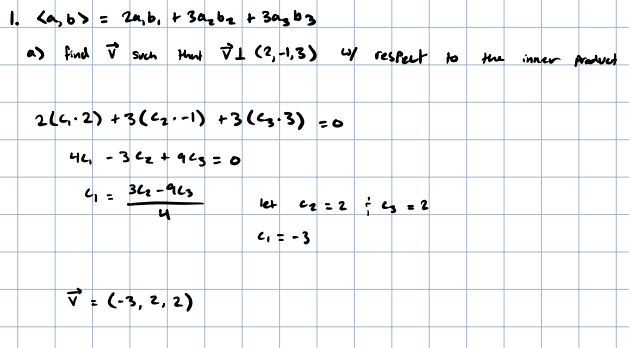

**<font color=red>QUESTION 1b:</font>** (1 point) <font color=blue> Find the magnitude (i.e length) of $\mathbf{a}$ with respect to the inner product in ($*$). 

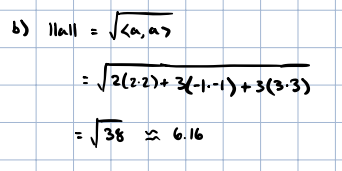

**<font color=red>QUESTION 1c:</font>** (2 points)  <font color=blue> **(BY HAND)** Let $\mathbf{c}=\left(7,3,-1\right)$. Find the projection $\text{proj}_{\mathbf{a}}\mathbf{c}$ with respect to the inner product in ($*$). 

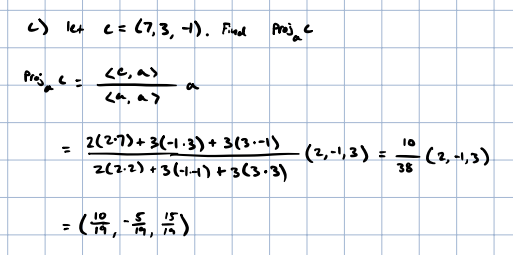

<font color=blue> Let $A=\begin{bmatrix}
 2 & 2 & 0 \\ -1 & 2 & 3\\ 3 & 4 & 1
 \end{bmatrix}$ and 
    $\mathbf{b}=\begin{bmatrix}
 7  \\ -1  \\ -4 
 \end{bmatrix}$

**<font color=red>QUESTION 1d:</font>**  <font color=blue>(1 point) By ONLY using Gauss elimination, solve the system $A\mathbf{x}=\mathbf{b}$. How many solutions do there exist?

In [2]:
# solution
A = np.array([
    [2, 2, 0, 7],
    [-1, 2, 3, -1],
    [3, 4, 1, -4]
])

sym.Matrix(A).rref()[0]

Matrix([
[1, 0, -1, 0],
[0, 1,  1, 0],
[0, 0,  0, 1]])

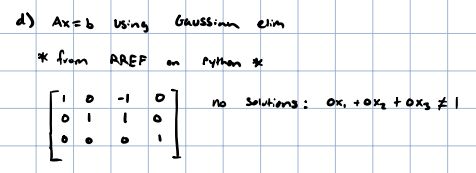

**<font color=red>QUESTION 1e:</font>**  <font color='blue'> (2 points) Find ALL $\mathbf{x}$ such that $A\mathbf{x}$ is as close to $\mathbf{b}$ as possible.

In [3]:
# solution
import numpy as np
import sympy as sym
A = np.array([
    [2, 2, 0],
    [-1, 2, 3],
    [3, 4, 1]
])

b = np.array([
    [7, -1, -4]
])

res_left = A.T @ A
res_right = A.T @ b.T

res = np.hstack((res_left, res_right))
sym.Matrix(res).rref()[0]

Matrix([
[1, 0, -1, 32/35],
[0, 1,  1, -7/10],
[0, 0,  0,     0]])

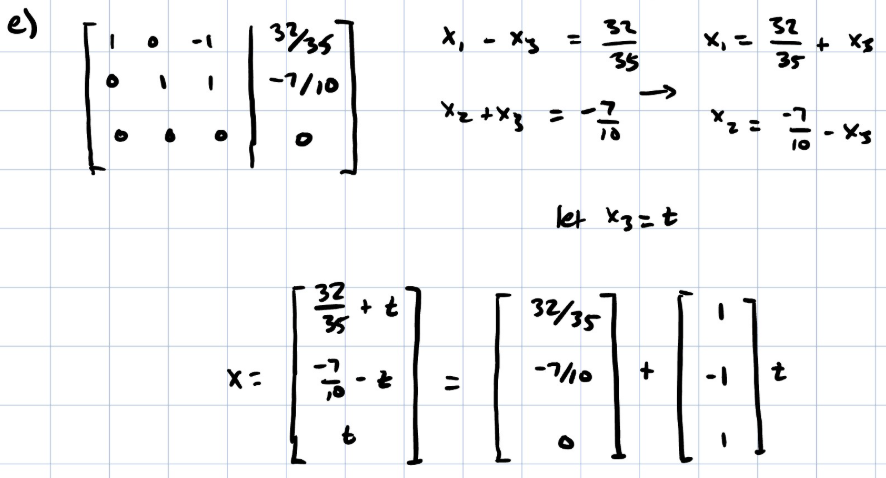

---
## Question 2: A Markov problem

<font color=blue> In a survey conducted on cellphone owners of Samsung, Pixel, iPhone, and Xiaomi, we gathered data on their preferences for their next cellphone in the event of a change from their current one. 

*<font color=blue> 60% of customers remain loyal to the same brand for their subsequent purchase.
    
*<font color=blue> Among current Xiaomi owners, 25% switch to Samsung, 5% to iPhone, and 10% to Pixel.
    
*<font color=blue> Similarly, among those having a Samsung now, 20% will buy a Xiaomi next, 15% will get an iPhone and 5% will buy a Pixel.
    
*<font color=blue> Meanwhile, among current iPhone owners, 10% will switch to Xiaomi, 10% to Samsung, and 20% to Pixel.

    
*<font color=blue> Finally, among Pixel owners, 10% switch to Xiaomi, while 30% opt for iPhone.
    

**<font color=red>QUESTION 2a:</font>** (4 points) <font color=blue> Find the state transition matrix for the above system. Let's consider Xiaomi = state 1, Samsung = state 2, iPhone = state 3, Pixel = state 4 and let $p_{ij}$ be the probability transition from state $j$ to state $i$. 

In [9]:
#solution

# | X  X  X  X |
# | S  S  S  S |
# | I  I  I  I |
# | P  P  P  P |

# col1 = Xiamoi owner, col2 = Samsung owner, col3 = iPhone owner, col4 = Pixel owner

P = np.array([
    [.6, .2, .1, .1],
    [.25, .6, .1, 0],
    [.05, .15, .6, .3],
    [.1, .05, .2, .6]
])

**<font color=red>QUESTION 2b:</font>** (1 point)  <font color=blue> Calculate the eigenvalues and eigenvectors of the model.

In [13]:
#solution
print("Eigenvalues")
sym.Matrix(P).eigenvals()

Eigenvalues


Eigenvectors


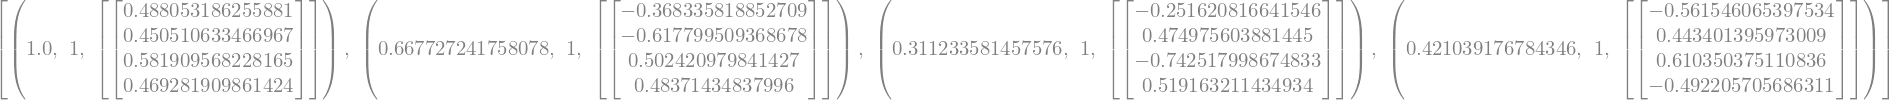

In [22]:
print("Eigenvectors")
sym.Matrix(P).eigenvects()

**<font color=red>QUESTION 2c:</font>**  (2 points) <font color=blue> Calculate the steady state of this model. Recall that the steady state vector is an eigenvector corresponding to the eigenvalue $1$ which is scaled so that the **sum** of its entries is $1$. 

In [34]:
ss_vector[0]**2

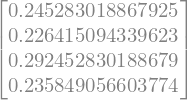

In [43]:
#solution
ss_vector = sym.Matrix(P).eigenvects()[0][2][0]
steady_state = np.zeros(shape=ss_vector.shape)
ss_sum = np.sum(ss_vector)

for i in range(ss_vector.shape[0]):
    steady_state[i] = ss_vector[i] / ss_sum

sym.Matrix(steady_state)

**<font color=red>QUESTION 2d:</font>**  (1 point) <font color=blue> Based on the long term steady state vector that you calculated, which cellphone brand is going to the most popular eventually? Explain how you came up with the answer.

In [48]:
#solution
comp = ["Xiamoi", "Samsung", "iPhone", "Pixel"]
idx = np.argmax(steady_state)
val = np.max(steady_state)

print("The maximum value of the steady state vector is {} located at index {} which corresponds to {}".format(
    round(val, 5), idx, comp[idx]))

The maximum value of the steady state vector is 0.29245 located at index 2 which corresponds to iPhone


**<font color=red>QUESTION 2e:</font>**  (1 point) <font color=blue> If there are exactly 20,000,000 buyers (assume this is constant), estimate how many people will be buying each cellphone brand in the long term?  Explain how you came up with your answer. You may approximate to the nearest integer.

In [57]:
# solution
num = 2e7

for i in range(len(comp)):
    buyers = round(steady_state[i][0] * num, 0)
    print("Company: {}. Number of expected buyers: {}".format(comp[i], buyers))

Company: Xiamoi. Number of expected buyers: 4905660.0
Company: Samsung. Number of expected buyers: 4528302.0
Company: iPhone. Number of expected buyers: 5849057.0
Company: Pixel. Number of expected buyers: 4716981.0


I came up with this answer by multiplying the probability defined in the steady state solution by the number of buyers.

----

## Question 3: Eigenvalues and eigenvectors (6 points)

**<font color=red>QUESTION 3a:</font>** (2 points)  <font color=blue> **(BY HAND)** Find the characteristic equation for the matrix $B=\begin{bmatrix}
 0 & 0 & -2\\ 1 & 2 & 1   \\ 1 & 0 & 3   \end{bmatrix}$. Show work.

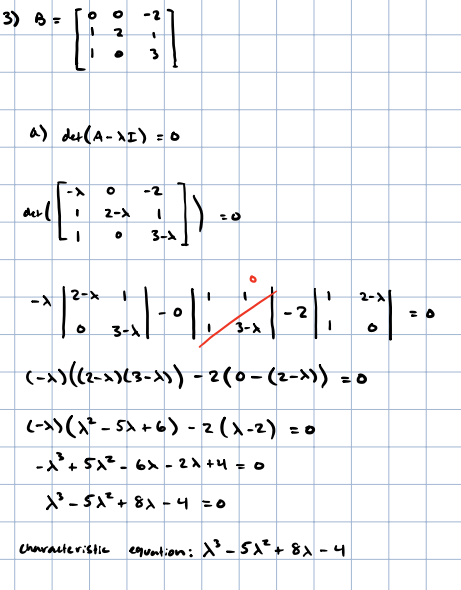

**<font color=red>QUESTION 3b:</font>** (1 point) <font color=blue> Using the characteristic equation, what are the eigenvalues of $B$?
    
[You are allowed to use a graphing calculator (e.g. Desmos) to see the graph of the polynomial of question 3a]

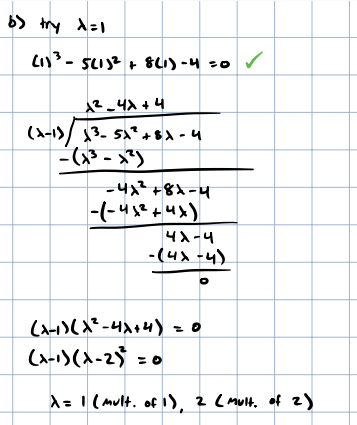

**<font color=red>QUESTION 3c:</font>** (4 points)  <font color=blue> **(BY HAND)** For the largest of the eigenvalues, find a basis for the corresponding eigenspace. Show work.

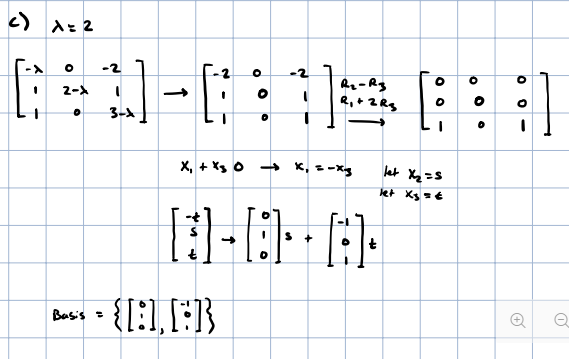

-----

## Before you close or submit this Homework, please make sure of two things:
- Did you save the file? `Ctrl + S` like everything else works!
- Is the file in correct format? For homeworks, you have to submit the file in `.pdf` format. 
 To do so, `Ctrl + P` and `Save as pdf` (on Windows) or `command + P` in mac.
- If that does not work, please Google "ipynb to pdf converter" and that should do the job.
- Are the pictures/images rendering correctly in the `.pdf` format?
- If the images are not rendering, you could also use this command in a cell:

`from IPython.display import display, Image`

`display(Image(filename="a.jpg", height=400, width=400))`

THIS ONLY WORKS WITH JPGS.

- Please make sure you submit the correct file filled-out file instead of an empty/blank file.

If you understand and agree that, print you name in the next code cell.

In [3]:
print("Mikel Good")

Mikel Good
